In [41]:
import numpy as np 
import tensorflow as tf 
import os 
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
img_rows, img_cols = 102, 136
DATA_PATH = './dataset/'

DATA_LIMIT = 500  # ini addition
RESULT_IMAGE = 16  # ini jg addition

x, y = [], []  # buat simpan gambar
counter = 0
classes = os.listdir(DATA_PATH)

print(classes)

['Boot', 'Sandal', 'Shoe']


In [43]:
for class_path in os.listdir(DATA_PATH):
    limit_counter = 0
    for img_path in os.listdir(f"{DATA_PATH}{class_path}"):  # os.path.join(DATA_PATH, class_path)
        
        # ini addition
        if limit_counter >= 100: continue
        limit_counter += 1
        
        path = f"{DATA_PATH}{class_path}/{img_path}"  # os.path.join(DATA_PATH, class_path, img_path)
        label = counter  # ngelabelin setiap kategori data
        image = tf.keras.preprocessing.image.load_img(path, target_size=(img_rows, img_cols))
        image = tf.keras.preprocessing.image.img_to_array(image)  # ubah gambar ke array, hasilnya bakal dalam angka
        x.append(image)
        y.append(label)
    counter += 1
    
x = np.array(x)
y = np.array(y)

x = x.astype('float32') / 255.0

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split (X_temp, y_temp, test_size=0.5, random_state=42)

y_train = tf.keras.utils.to_categorical(y_train, num_classes=3)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=3)
y_val = tf.keras.utils.to_categorical(y_val, num_classes=3)

print(X_train.shape)

(240, 102, 136, 3)


In [44]:
x.shape

(300, 102, 136, 3)

In [45]:
model = tf.keras.Sequential()
model.add(tf.keras.layers.Conv2D(6, (5,5), activation='relu', input_shape=(img_rows, img_cols, 3)))  # dibagi jadi 6 matrix trs dipooling
model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2))
model.add(tf.keras.layers.Conv2D(16, (5,5), activation='relu'))
model.add(tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(120, activation='relu'))
model.add(tf.keras.layers.Dense(84, activation='relu'))
model.add(tf.keras.layers.Dense(3, activation='softmax'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 98, 132, 6)        456       
                                                                 
 average_pooling2d_8 (Averag  (None, 49, 66, 6)        0         
 ePooling2D)                                                     
                                                                 
 conv2d_9 (Conv2D)           (None, 45, 62, 16)        2416      
                                                                 
 average_pooling2d_9 (Averag  (None, 22, 31, 16)       0         
 ePooling2D)                                                     
                                                                 
 flatten_4 (Flatten)         (None, 10912)             0         
                                                                 
 dense_12 (Dense)            (None, 120)              

In [58]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics='accuracy')
history = model.fit(X_train, y_train, batch_size=120, validation_data=(X_val, y_val), epochs=10)

Epoch 1/10
2/2 [==============================] - 1s 430ms/step - loss: 1.6487 - accuracy: 0.7083 - val_loss: 0.5218 - val_accuracy: 0.8000
Epoch 2/10
2/2 [==============================] - 1s 283ms/step - loss: 0.6019 - accuracy: 0.7958 - val_loss: 0.7362 - val_accuracy: 0.7333
Epoch 3/10
2/2 [==============================] - 1s 290ms/step - loss: 0.5752 - accuracy: 0.7458 - val_loss: 0.7092 - val_accuracy: 0.5667
Epoch 4/10
2/2 [==============================] - 1s 291ms/step - loss: 0.4699 - accuracy: 0.8333 - val_loss: 0.5836 - val_accuracy: 0.8667
Epoch 5/10
2/2 [==============================] - 1s 288ms/step - loss: 0.4670 - accuracy: 0.9250 - val_loss: 0.4620 - val_accuracy: 0.9000
Epoch 6/10
2/2 [==============================] - 1s 290ms/step - loss: 0.3676 - accuracy: 0.9333 - val_loss: 0.3906 - val_accuracy: 0.8333
Epoch 7/10
2/2 [==============================] - 1s 290ms/step - loss: 0.2978 - accuracy: 0.9250 - val_loss: 0.3080 - val_accuracy: 0.8333
Epoch 8/10
2/2 [====

In [47]:
prediction = model.predict(X_test)
print(prediction)
prediction_labels = np.argmax(prediction, axis=1)

1/1 [==============================] - 0s 63ms/step
[[2.85832561e-03 9.52425227e-02 9.01899159e-01]
 [2.11124197e-02 7.18976974e-01 2.59910554e-01]
 [1.71053987e-02 9.69359100e-01 1.35354931e-02]
 [2.51927623e-03 7.12646097e-02 9.26216125e-01]
 [8.54377985e-01 1.32789165e-01 1.28329210e-02]
 [8.71100843e-01 1.13765143e-01 1.51340710e-02]
 [2.05180198e-01 7.67730534e-01 2.70892233e-02]
 [5.65767944e-01 4.09943223e-01 2.42888015e-02]
 [7.58653641e-01 1.93143949e-01 4.82024103e-02]
 [3.57899070e-03 1.51825115e-01 8.44595969e-01]
 [9.58583474e-01 3.78435142e-02 3.57305794e-03]
 [3.19307903e-03 2.70045386e-03 9.94106412e-01]
 [1.82704348e-02 8.98419917e-01 8.33096653e-02]
 [3.84682268e-01 2.68825054e-01 3.46492618e-01]
 [4.98473160e-02 4.13739234e-01 5.36413431e-01]
 [9.75202501e-01 2.23262683e-02 2.47117109e-03]
 [1.90732088e-02 7.98035324e-01 1.82891563e-01]
 [3.40979435e-02 1.26424119e-01 8.39477956e-01]
 [2.45847702e-02 6.57042205e-01 3.18373054e-01]
 [7.72270653e-03 1.05367757e-01 8.86

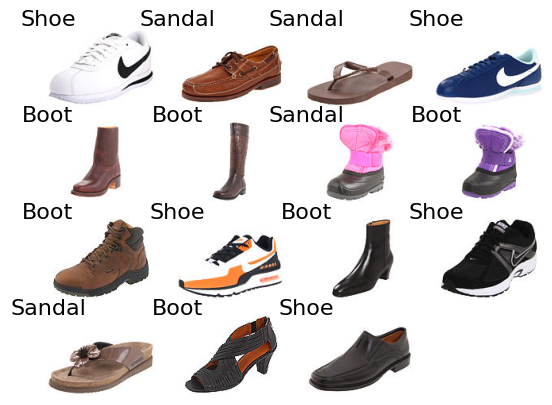

In [56]:
for i in range(RESULT_IMAGE):
    plt.subplot(4,4, i+1)
    plt.imshow(X_test[i], cmap='gray')
    plt.axis(False)
    plt.text(0.5, -0.15, classes[prediction_labels[i]], fontsize=16, ha='center')

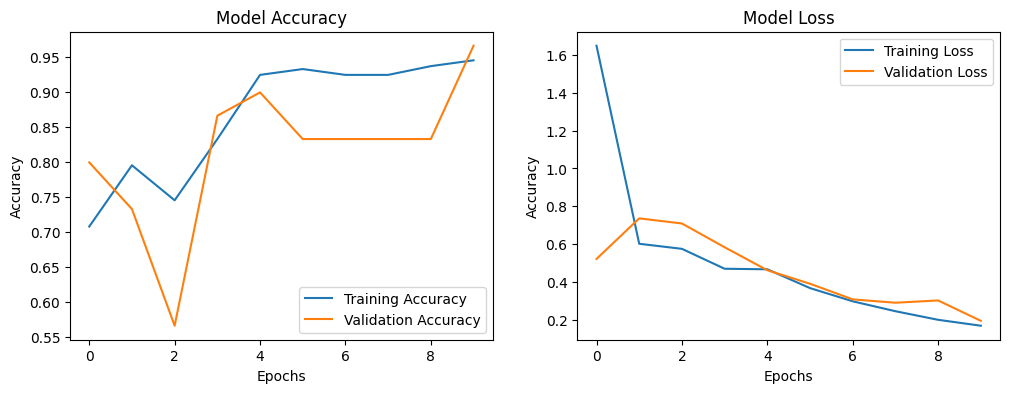

In [65]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Loss')
plt.legend()
plt.show()